# 4PL model for ELISA result calculation

This project demonstrates a Python-based four-parameter logistic (4PL) model developed to automate quantitative ELISA result calculations. Previously, assay results were calculated using GraphPad Prism, which occasionally led to inconsistencies because users did not always analyse data using identical settings or workflows. The workflow was developed to reduce analysis time while improving consistency, reproducibility, and confidence in the reported results.

The automated workflow was designed to:

- Reduce manual data processing and provide faster result review.
- Standardize analysis by using a consistent fitting workflow.
- Quickly assess assay quality through automated curve fitting and quality metrics.
- Generate calibration curves and calculate sample concentrations automatically.

### About the Workflow

For demonstration purposes, a standard curve ranging from 0–500 ng/mL and representative ELISA optical density (OD) values were generated. The original workflow was designed to operate directly from Excel, where experimental values were entered into predefined cells and all calculations, curve fitting, and result reporting were performed automatically.

Initial parameter estimates were based on observed OD ranges, concentration distributions, and previously validated assay fits. The calculated concentrations were compared against GraphPad Prism results to verify performance, demonstrating 95–105% agreement within the quantitative range while providing a standardized and reproducible analysis workflow.

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Standard concentrations (ng/mL)
x = np.array([0, 7.81, 15.63, 31.25, 62.5, 125, 250, 500], dtype=float)

#Converting expected concentrations into logarithmic values
logx = np.log10(x[1:])
scaled = (logx - logx.min()) / (logx.max() - logx.min())

# Generate ELISA-like OD values
y = np.zeros_like(x)

y[0] = 0.05  # blank
y[1:] = 0.05 + 2.4 / (1 + np.exp(-8 * (scaled - 0.55)))

# Add experimental noise
y += np.random.normal(0, 0.03, len(y))

Top Asympote: 2.509580261320363
Slope: 1.8293795780795834
Inflection point: 78.87386152653994
Bottom Asympote; 0.05238651040106242
Standard Curve Coefficient: 0.9996340900808285


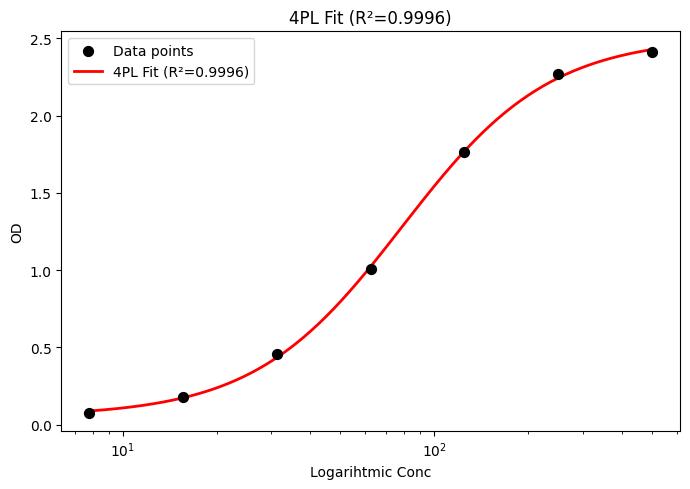

In [3]:
# Remove zero/negative x (blank standard)
mask = x > 0
x = x[mask]
y = y[mask]
logx = np.log10(x)

# 4PL in log-space (GraphPad-equivalent)
def four_pl(logx, A, B, logEC50, D):
    return D + (A - D) / (1 + 10**((logEC50 - logx) * B))

# Initial guesses + bounds to anchor the fit correctly
p0 = [max(y)*2, 1.4, np.log10(np.median(x)), min(y)]
bounds = ([0, 0.01, -1, -0.05], [50, 10, 4, 0.5])


p, _ = curve_fit(four_pl, logx, y, p0=p0, bounds=bounds, method='trf',
                 ftol=1e-15, xtol=1e-15, gtol=1e-15, maxfev=100000)

A, B, logEC50, D = p
C = 10**logEC50

# R²
y_pred = four_pl(logx, A, B, logEC50, D)
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

# Smooth curve for plotting
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
y_smooth = four_pl(np.log10(x_smooth), A, B, logEC50, D)

# Calibration curve
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("none")
ax.patch.set_color("none")
ax.scatter(x, y, color='black', zorder=5, label='Data points', s=50)
ax.plot(x_smooth, y_smooth, color='red', linewidth=2, label=f'4PL Fit (R²={r2:.4f})')
ax.set_xscale('log')
ax.set_xlabel('Logarihtmic Conc')
ax.set_ylabel('OD')
ax.set_title(f'4PL Fit (R²={r2:.4f})')
ax.legend()
plt.tight_layout()


print("Top Asympote:",A)
print("Slope:",B)
print("Inflection point:",C)
print("Bottom Asympote;",D)
print("Standard Curve Coefficient:",r2)    

In [4]:
#Example Calculated Result
C*((A-D)/(y[3]-D)-1)**(1/(-B))

61.51161047964638